<a href="https://colab.research.google.com/github/jayachandiran-ux/Turbofan-Engine-Remaining-Useful-Life-Prediction/blob/main/Turbofan_Engine_Remaining_Useful_Life_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os

print(os.listdir("/content"))

['.config', 'Project6_Pdm_Predict the number of remaining operational cycles before failure for Turbofan engine (1).zip', 'sample_data']


In [ ]:
import zipfile

zip_path = "/content/Project6_Pdm_Predict the number of remaining operational cycles before failure for Turbofan engine (1).zip"
extract_path = "/content/Project6"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("✅ Extraction Completed Successfully!")

✅ Extraction Completed Successfully!


In [ ]:
import os

print(os.listdir("/content/Project6"))

['Project6_Pdm_Predict the number of remaining operational cycles before failure for Turbofan engine']


In [ ]:
import os

folder = "/content/Project6/Project6_Pdm_Predict the number of remaining operational cycles before failure for Turbofan engine"

print(os.listdir(folder))

['Project6_Pdm_Predict the number of remaining operational cycles before failure for Turbofan engine.docx', 'Project6_Pdm_Predict the number of remaining operational cycles before failure for Turbofan engine.zip']


In [ ]:
import zipfile

inner_zip = "/content/Project6/Project6_Pdm_Predict the number of remaining operational cycles before failure for Turbofan engine/Project6_Pdm_Predict the number of remaining operational cycles before failure for Turbofan engine.zip"

extract_path = "/content/Project6/Dataset"

with zipfile.ZipFile(inner_zip, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("✅ Inner ZIP Extracted Successfully!")

✅ Inner ZIP Extracted Successfully!


In [ ]:
import os

print(os.listdir("/content/Project6/Dataset"))

['Turbofan engine']


In [ ]:
import os

folder = "/content/Project6/Dataset/Turbofan engine"

print(os.listdir(folder))

['RUL_FD004.txt', 'test_FD001.txt', 'train_FD003.txt', 'test_FD003.txt', 'train_FD002.txt', 'readme.txt', 'Damage Propagation Modeling.pdf', 'train_FD001.txt', 'test_FD004.txt', 'RUL_FD003.txt', 'RUL_FD001.txt', 'test_FD002.txt', 'train_FD004.txt', 'RUL_FD002.txt', 'RUL_reader.py']


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
columns = [
    'unit_number', 'time_cycles',
    'op_setting1', 'op_setting2', 'op_setting3'
]

for i in range(1,22):
    columns.append(f'sensor_{i}')

train = pd.read_csv(
    "/content/Project6/Dataset/Turbofan engine/train_FD001.txt",
    sep=r"\s+",
    header=None
)

train = train.iloc[:, :26]
train.columns = columns

train.head()

,unit_number,time_cycles,op_setting1,op_setting2,op_setting3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [ ]:
train.shape

(20631, 26)

In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20631 entries, 0 to 20630
Data columns (total 26 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   unit_number  20631 non-null  int64  
 1   time_cycles  20631 non-null  int64  
 2   op_setting1  20631 non-null  float64
 3   op_setting2  20631 non-null  float64
 4   op_setting3  20631 non-null  float64
 5   sensor_1     20631 non-null  float64
 6   sensor_2     20631 non-null  float64
 7   sensor_3     20631 non-null  float64
 8   sensor_4     20631 non-null  float64
 9   sensor_5     20631 non-null  float64
 10  sensor_6     20631 non-null  float64
 11  sensor_7     20631 non-null  float64
 12  sensor_8     20631 non-null  float64
 13  sensor_9     20631 non-null  float64
 14  sensor_10    20631 non-null  float64
 15  sensor_11    20631 non-null  float64
 16  sensor_12    20631 non-null  float64
 17  sensor_13    20631 non-null  float64
 18  sensor_14    20631 non-null  float64
 19  sens

In [ ]:
max_cycle = train.groupby('unit_number')['time_cycles'].max().reset_index()
max_cycle.columns = ['unit_number', 'max_cycle']

train = train.merge(max_cycle, on='unit_number')

train['RUL'] = train['max_cycle'] - train['time_cycles']

train.drop('max_cycle', axis=1, inplace=True)

train.head()

,unit_number,time_cycles,op_setting1,op_setting2,op_setting3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,191
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,190
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,189
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,188
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,187


In [ ]:
train[['unit_number', 'time_cycles', 'RUL']].head(20)

,unit_number,time_cycles,RUL
0,1,1,191
1,1,2,190
2,1,3,189
3,1,4,188
4,1,5,187
5,1,6,186
6,1,7,185
7,1,8,184
8,1,9,183
9,1,10,182


In [ ]:
X = train.drop(['unit_number', 'time_cycles', 'RUL'], axis=1)

y = train['RUL']

print(X.shape)
print(y.shape)

(20631, 24)
(20631,)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

print("✅ Model Trained Successfully")

✅ Model Trained Successfully


In [ ]:
y_pred = model.predict(X_valid)

print(y_pred[:10])

[135.34   9.98 170.84   1.74 138.08 114.1  115.38  95.11  82.07 155.92]


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_valid, y_pred)
rmse = np.sqrt(mean_squared_error(y_valid, y_pred))
r2 = r2_score(y_valid, y_pred)

print("Mean Absolute Error :", mae)
print("Root Mean Squared Error :", rmse)
print("R2 Score :", r2)

Mean Absolute Error : 29.688841773685485
Root Mean Squared Error : 41.5214287563132
R2 Score : 0.6226512682402188


In [ ]:
comparison = pd.DataFrame({
    "Actual RUL": y_valid.values,
    "Predicted RUL": y_pred
})

comparison.head(20)

,Actual RUL,Predicted RUL
0,135,135.34
1,2,9.98
2,217,170.84
3,0,1.74
4,178,138.08
5,70,114.10
6,87,115.38
7,87,95.11
8,73,82.07
9,77,155.92


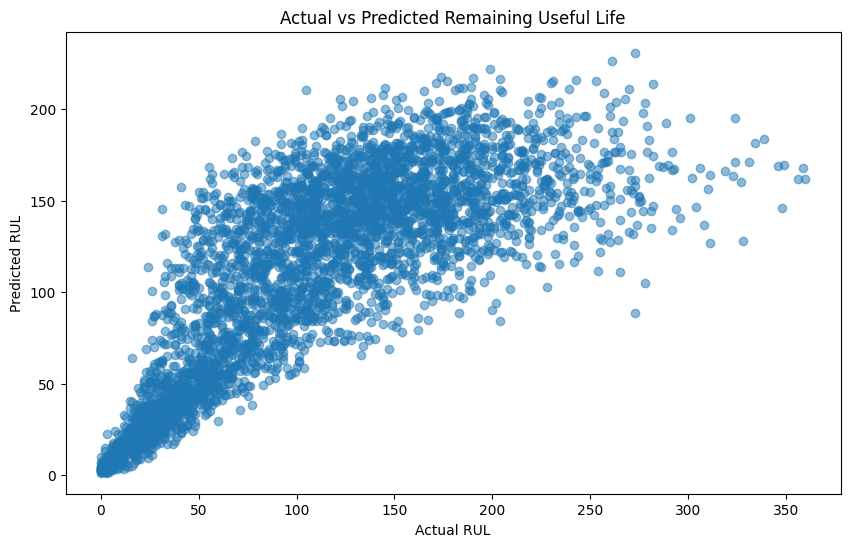

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.scatter(y_valid, y_pred, alpha=0.5)

plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")
plt.title("Actual vs Predicted Remaining Useful Life")

plt.show()

In [ ]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(by="Importance", ascending=False)

importance.head(10)

,Feature,Importance
13,sensor_11,0.401813
11,sensor_9,0.122583
6,sensor_4,0.121062
14,sensor_12,0.052464
9,sensor_7,0.037132
16,sensor_14,0.035848
23,sensor_21,0.032169
17,sensor_15,0.030902
5,sensor_3,0.027355
4,sensor_2,0.027044


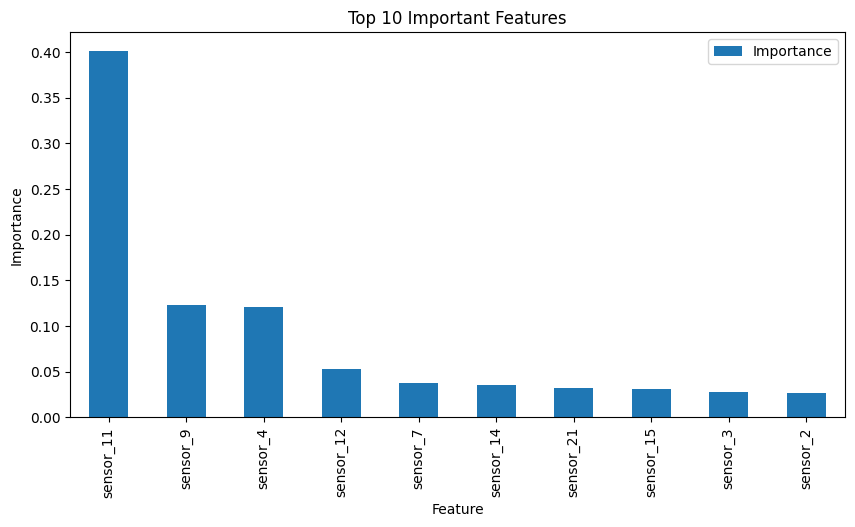

In [ ]:
importance.head(10).plot(
    x="Feature",
    y="Importance",
    kind="bar",
    figsize=(10,5)
)

plt.title("Top 10 Important Features")
plt.ylabel("Importance")
plt.show()

In [ ]:
test = pd.read_csv(
    "/content/Project6/Dataset/Turbofan engine/test_FD001.txt",
    sep=r"\s+",
    header=None
)

test = test.iloc[:, :26]
test.columns = columns

test.head()

,unit_number,time_cycles,op_setting1,op_setting2,op_setting3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,0.0023,0.0003,100.0,518.67,643.02,1585.29,1398.21,14.62,...,521.72,2388.03,8125.55,8.4052,0.03,392,2388,100.0,38.86,23.3735
1,1,2,-0.0027,-0.0003,100.0,518.67,641.71,1588.45,1395.42,14.62,...,522.16,2388.06,8139.62,8.3803,0.03,393,2388,100.0,39.02,23.3916
2,1,3,0.0003,0.0001,100.0,518.67,642.46,1586.94,1401.34,14.62,...,521.97,2388.03,8130.10,8.4441,0.03,393,2388,100.0,39.08,23.4166
3,1,4,0.0042,0.0000,100.0,518.67,642.44,1584.12,1406.42,14.62,...,521.38,2388.05,8132.90,8.3917,0.03,391,2388,100.0,39.00,23.3737
4,1,5,0.0014,0.0000,100.0,518.67,642.51,1587.19,1401.92,14.62,...,522.15,2388.03,8129.54,8.4031,0.03,390,2388,100.0,38.99,23.4130


In [ ]:
rul = pd.read_csv(
    "/content/Project6/Dataset/Turbofan engine/RUL_FD001.txt",
    header=None
)

rul.columns = ["Actual_RUL"]

rul.head()

,Actual_RUL
0,112
1,98
2,69
3,82
4,91


In [ ]:
X_test = test.drop(["unit_number", "time_cycles"], axis=1)

print(X_test.shape)

(13096, 24)


In [ ]:
print(X.columns.tolist())
print(X_test.columns.tolist())

['op_setting1', 'op_setting2', 'op_setting3', 'sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_16', 'sensor_17', 'sensor_18', 'sensor_19', 'sensor_20', 'sensor_21']
['op_setting1', 'op_setting2', 'op_setting3', 'sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_16', 'sensor_17', 'sensor_18', 'sensor_19', 'sensor_20', 'sensor_21']


In [ ]:
test_predictions = model.predict(X_test)

print(test_predictions[:10])

[185.14 164.91 166.22 171.97 192.59 204.31 167.79 165.24 185.74 180.02]


In [ ]:
last_test = test.groupby("unit_number").tail(1)

X_last = last_test.drop(["unit_number", "time_cycles"], axis=1)

final_predictions = model.predict(X_last)

print(final_predictions[:10])
print("Total Predictions:", len(final_predictions))

[162.98 149.4   53.52 109.9  121.8  118.9  125.29 108.93 126.76 129.88]
Total Predictions: 100


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

actual = rul["Actual_RUL"]

mae = mean_absolute_error(actual, final_predictions)
rmse = np.sqrt(mean_squared_error(actual, final_predictions))
r2 = r2_score(actual, final_predictions)

print("Final Test MAE :", mae)
print("Final Test RMSE :", rmse)
print("Final Test R2 :", r2)

Final Test MAE : 24.606599999999993
Final Test RMSE : 33.373164638673394
Final Test R2 : 0.355036351326122


In [ ]:
comparison = pd.DataFrame({
    "Actual": actual,
    "Predicted": final_predictions
})

comparison.head(20)

,Actual,Predicted
0,112,162.98
1,98,149.40
2,69,53.52
3,82,109.90
4,91,121.80
5,93,118.90
6,91,125.29
7,95,108.93
8,111,126.76
9,96,129.88


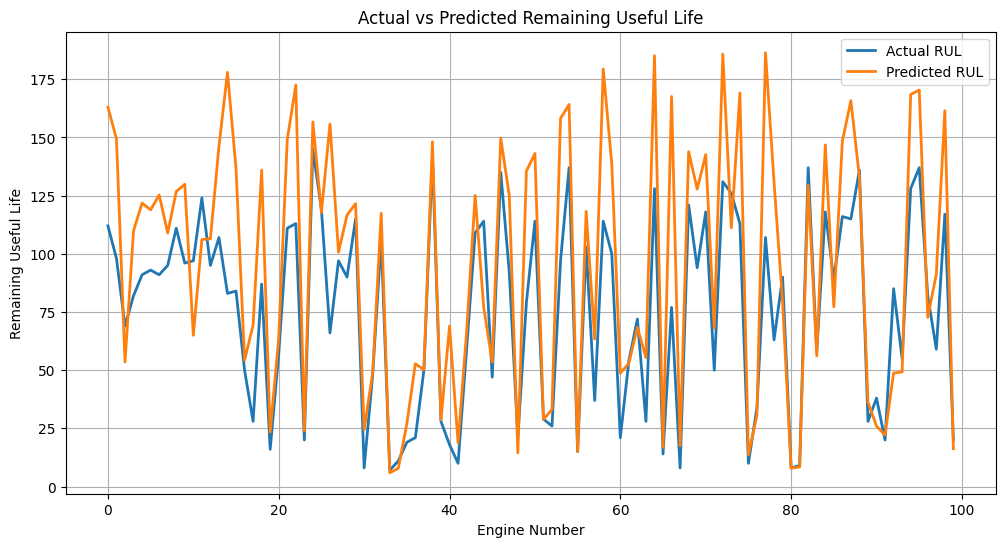

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(actual.values, label="Actual RUL", linewidth=2)
plt.plot(final_predictions, label="Predicted RUL", linewidth=2)

plt.title("Actual vs Predicted Remaining Useful Life")
plt.xlabel("Engine Number")
plt.ylabel("Remaining Useful Life")

plt.legend()
plt.grid(True)

plt.show()